# Ejecución y Validación del IAI

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.ticker as mticker

#importamos motor logico del IAI
module_path = os.path.abspath(os.path.join('..')) 

if module_path not in sys.path:
    sys.path.append(module_path)
from src.IAI_estimador import calculate_iai


In [6]:
OUTPUT_DIR = "resultados_IAI"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path,dpi=300, bbox_inches="tight")
    print(f"  [guardado] {path}")
   

In [4]:
#Cargamos el Dataaset historico limpio
df_hist_clean = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_clean.parquet")

# Calcular Índice de Idoneidad Agroclimática (IAI)

In [5]:
# Aplicamos la función vectorizada 
df_iai_hist = calculate_iai(df_hist_clean)

# Extraemos los valores para graficar
iai_values = df_iai_hist["IAI"].to_numpy()

print(f" IAI calculado exitosamente para {len(iai_values):,} parcelas.")

 IAI calculado exitosamente para 633,904 parcelas.


  [guardado] resultados_IAI\hist_distribucion_iai.png


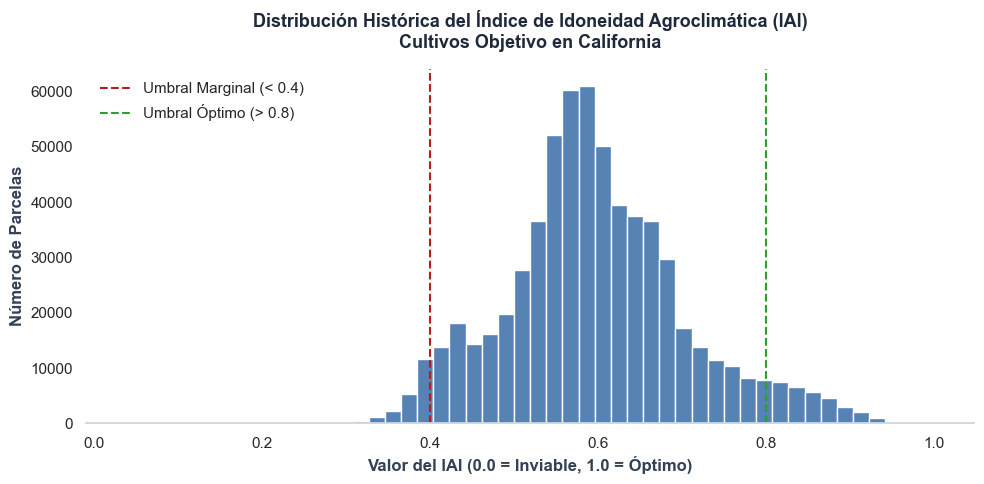

statistic,IAI
str,f64
"""count""",633904.0
"""null_count""",0.0
"""mean""",0.59692
"""std""",0.107543
"""min""",0.038889
"""25%""",0.534761
"""50%""",0.588364
"""75%""",0.657238
"""max""",1.0


In [6]:
# HISTOGRAMA DE VALIDACIÓN

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma con la paleta institucional
sns.histplot(iai_values, bins=50, color="#4374ac", edgecolor="white", alpha=0.9, ax=ax)

# Líneas de corte analítico
ax.axvline(0.4, color='#b91c1c', linestyle='--', linewidth=1.5, label='Umbral Marginal (< 0.4)')
ax.axvline(0.8, color='#2ca02c', linestyle='--', linewidth=1.5, label='Umbral Óptimo (> 0.8)')

# Estética
ax.set_title("Distribución Histórica del Índice de Idoneidad Agroclimática (IAI)\nCultivos Objetivo en California", 
             fontsize=13, fontweight="bold", pad=15, color="#1e293b")
ax.set_xlabel("Valor del IAI (0.0 = Inviable, 1.0 = Óptimo)", fontweight="bold", color="#334155")
ax.set_ylabel("Número de Parcelas", fontweight="bold", color="#334155")

ax.grid(False)
sns.despine(left=True, bottom=False)
ax.spines['bottom'].set_color('#cbd5e1')
ax.legend(frameon=False)

plt.tight_layout()
save(fig, "hist_distribucion_iai.png")
plt.show()

# Resumen estadístico
display(df_iai_hist.select("IAI").describe())

In [7]:
# Componendes del IAI
pl.Config.set_tbl_rows(30)
# Calculamos la media de cada componente individual para toda California
componentes = df_iai_hist.select(["I_GDD", "I_temp", "I_precip", "I_suelo"]).mean()
display(componentes)

# Y para ver si el problema es general o de un cultivo en específico:
print("\n PROMEDIO DEL ÍNDICE DE TEMPERATURA POR CULTIVO:")
display(df_iai_hist.group_by("crop_name").agg(pl.col("I_temp").mean()).sort("I_temp"))

I_GDD,I_temp,I_precip,I_suelo
f64,f64,f64,f64
0.732092,0.913091,0.127594,0.585606



 PROMEDIO DEL ÍNDICE DE TEMPERATURA POR CULTIVO:


crop_name,I_temp
str,f64
"""Lettuce""",0.113423
"""Wheat""",0.507872
"""Alfalfa""",0.906797
"""Pistachios""",0.980777
"""Strawberries""",0.994365
"""Oranges""",0.99748
"""Grapes""",0.99798
"""Tomatoes""",0.998851
"""Cotton""",0.999222


In [8]:
# Verificar de dónde vienen las 48 filas faltantes
print("Nulos por columna relevante:")
for col in ["tmax", "tmin", "ppt", "ph1to1h2o_r", "profundidad_efectiva_cm", "awc_r", "IAI"]:
    print(f"  {col}: {df_iai_hist.select(pl.col(col).is_null().sum()).item()}")

Nulos por columna relevante:
  tmax: 0
  tmin: 0
  ppt: 0
  ph1to1h2o_r: 0
  profundidad_efectiva_cm: 0
  awc_r: 0
  IAI: 0


In [15]:
print("Filas totales:", df_iai_hist.shape[0])
print("Filas únicas (year, crop_id, lon, lat):",
      df_iai_hist
      .with_columns([
          pl.col("location").struct.field("coordinates").list.get(0).alias("lon"),
          pl.col("location").struct.field("coordinates").list.get(1).alias("lat")
      ])
      .select(["year", "crop_id", "lon", "lat"])
      .n_unique())

Filas totales: 633904
Filas únicas (year, crop_id, lon, lat): 633904


In [ ]:
df_iai_hist.write_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai.parquet")


## EDA2: IAI Vs variables 

In [18]:
# ------------------------------------------------------------
# Estilo visual académico (paleta consistente con la memoria)
# ------------------------------------------------------------
COLOR_MAIN   = "#2e5b94"   # azul principal
COLOR_GREEN  = "#4a7c59"   # verde
COLOR_GRAY   = "#6b6b6b"   # gris
COLOR_ORANGE = "#d98c3f"   # naranja (acentos)
PALETA = [COLOR_MAIN, COLOR_GREEN, COLOR_GRAY, COLOR_ORANGE,
          "#7098c4", "#8ab08f", "#a88b6b", "#b5651d",
          "#3d6b52", "#264d7a", "#9a9a9a", "#c47f3d"]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

# Mostrar todas las filas y columnas sin truncar
pl.Config.set_tbl_rows(-1)        # todas las filas (-1 = sin límite)
pl.Config.set_tbl_cols(-1)        # todas las columnas
pl.Config.set_fmt_str_lengths(100)  # no cortar strings largos
pl.Config.set_tbl_width_chars(200)  # ancho total de la tabla


polars.config.Config

In [3]:
df = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai.parquet")

In [4]:
# ------------------------------------------------------------
# Definición de grupos de variables
# ------------------------------------------------------------
vars_clima = ["tmax", "tmin", "ppt", "vpdmax", "vpdmin"]
vars_suelo = ["ph1to1h2o_r", "awc_r", "claytotal_r",
              "sandtotal_r", "silttotal_r", "dbthirdbar_r"]
vars_base  = vars_clima + vars_suelo
subindices = ["I_GDD", "I_temp", "I_precip", "I_suelo"]

# Etiquetas legibles para los gráficos
NOMBRES = {
    "tmax": "Temp. máxima (°C)", "tmin": "Temp. mínima (°C)",
    "ppt": "Precipitación (mm)", "vpdmax": "VPD máx (hPa)",
    "vpdmin": "VPD mín (hPa)", "ph1to1h2o_r": "pH del suelo",
    "awc_r": "Cap. agua disp. (cm/cm)", "claytotal_r": "Arcilla (%)",
    "sandtotal_r": "Arena (%)", "silttotal_r": "Limo (%)",
    "dbthirdbar_r": "Densidad aparente (g/cm³)",
    "I_GDD": "I_GDD (térmico)", "I_temp": "I_temp",
    "I_precip": "I_precip", "I_suelo": "I_suelo", "IAI": "IAI",
}

# Verificar que las columnas existen
faltantes = [c for c in vars_base + subindices + ["IAI"] if c not in df.columns]
print("Columnas faltantes:", faltantes if faltantes else "ninguna")

Columnas faltantes: ninguna


### IAI frente a los subíndices

Media de cada subíndice:
shape: (1, 4)
┌──────────┬──────────┬──────────┬──────────┐
│ I_GDD    ┆ I_temp   ┆ I_precip ┆ I_suelo  │
│ ---      ┆ ---      ┆ ---      ┆ ---      │
│ f64      ┆ f64      ┆ f64      ┆ f64      │
╞══════════╪══════════╪══════════╪══════════╡
│ 0.732092 ┆ 0.913091 ┆ 0.127594 ┆ 0.585606 │
└──────────┴──────────┴──────────┴──────────┘


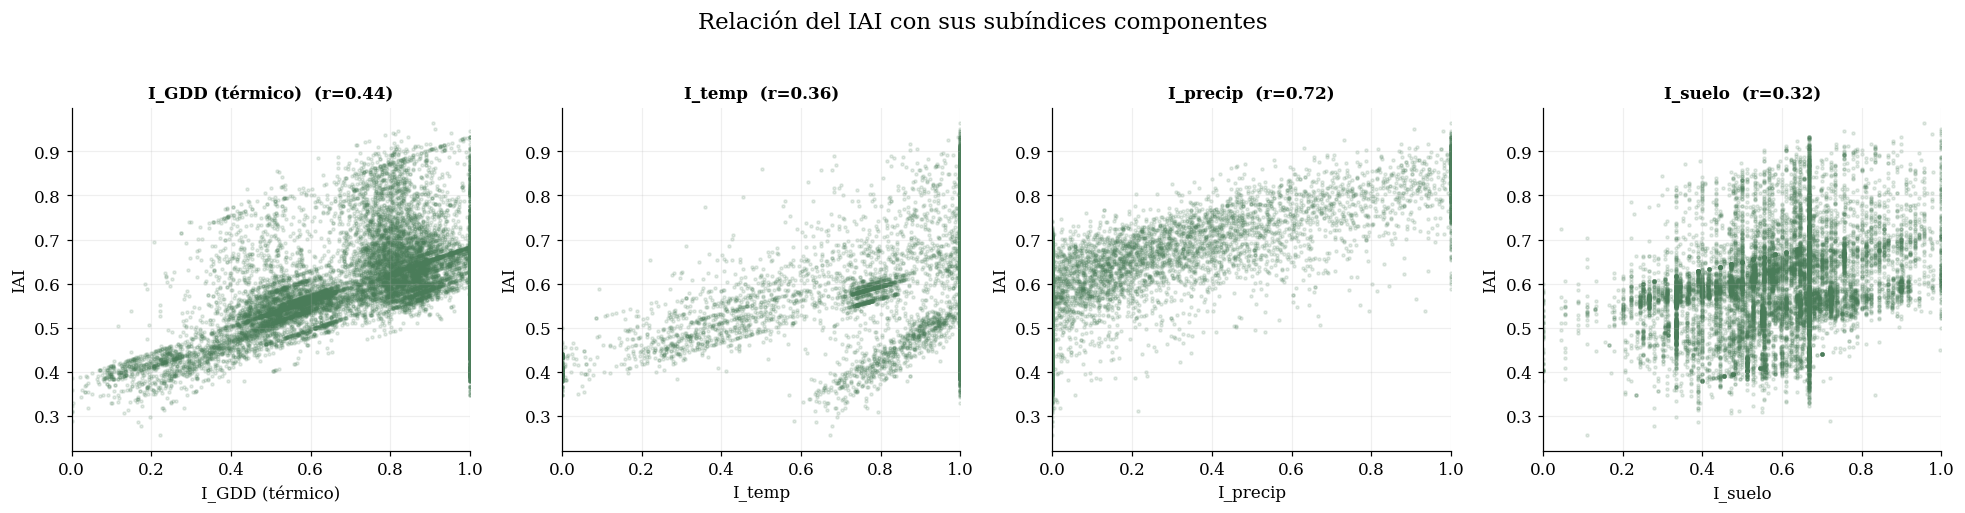

In [8]:
# Medias de los subíndices (identifica factores limitantes)
print("Media de cada subíndice:")
print(df.select(subindices).mean())

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for i, sub in enumerate(subindices):
    ax = axes[i]
    x = df_s[sub].to_numpy()
    y = df_s["IAI"].to_numpy()
    ax.scatter(x, y, s=4, alpha=0.15, color=COLOR_GREEN)
    # correlación
    r = np.corrcoef(df[sub].to_numpy(), df["IAI"].to_numpy())[0, 1]
    ax.set_title(f"{NOMBRES.get(sub, sub)}  (r={r:.2f})", fontsize=11)
    ax.set_xlabel(NOMBRES.get(sub, sub))
    ax.set_ylabel("IAI")
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.2)

plt.suptitle("Relación del IAI con sus subíndices componentes", fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_03_iai_vs_subindices.png"), dpi=300, bbox_inches="tight")
plt.show()

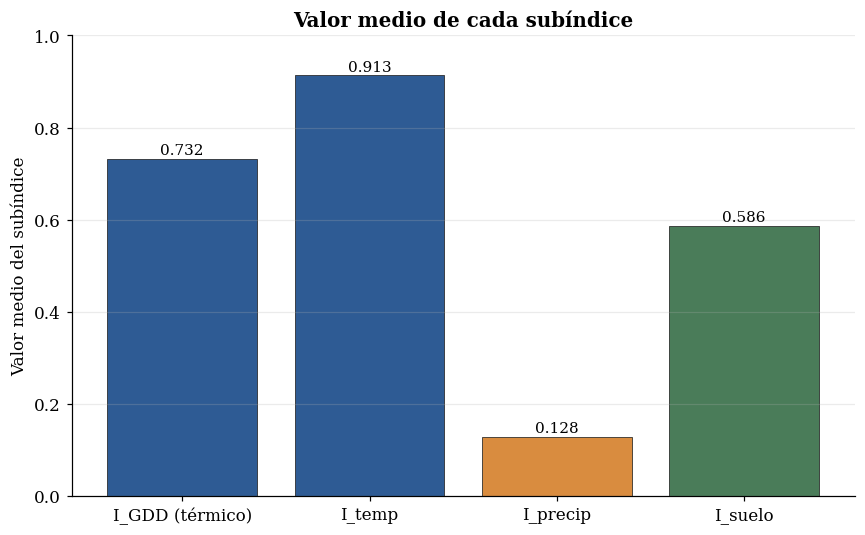

In [10]:
# Media de subíndices como gráfico de barras (visión de factores limitantes)
medias_sub = [df[s].mean() for s in subindices]

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar([NOMBRES[s] for s in subindices], medias_sub,
                color=[COLOR_MAIN, COLOR_MAIN, COLOR_ORANGE, COLOR_GREEN],
                edgecolor="#222", linewidth=0.5)
for b, v in zip(barras, medias_sub):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}",
            ha="center", fontsize=10)
ax.set_ylabel("Valor medio del subíndice")
ax.set_ylim(0, 1)
ax.set_title("Valor medio de cada subíndice")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_04_medias_subindices.png"), dpi=300, bbox_inches="tight")
plt.show()

### IAI frente a las variables base

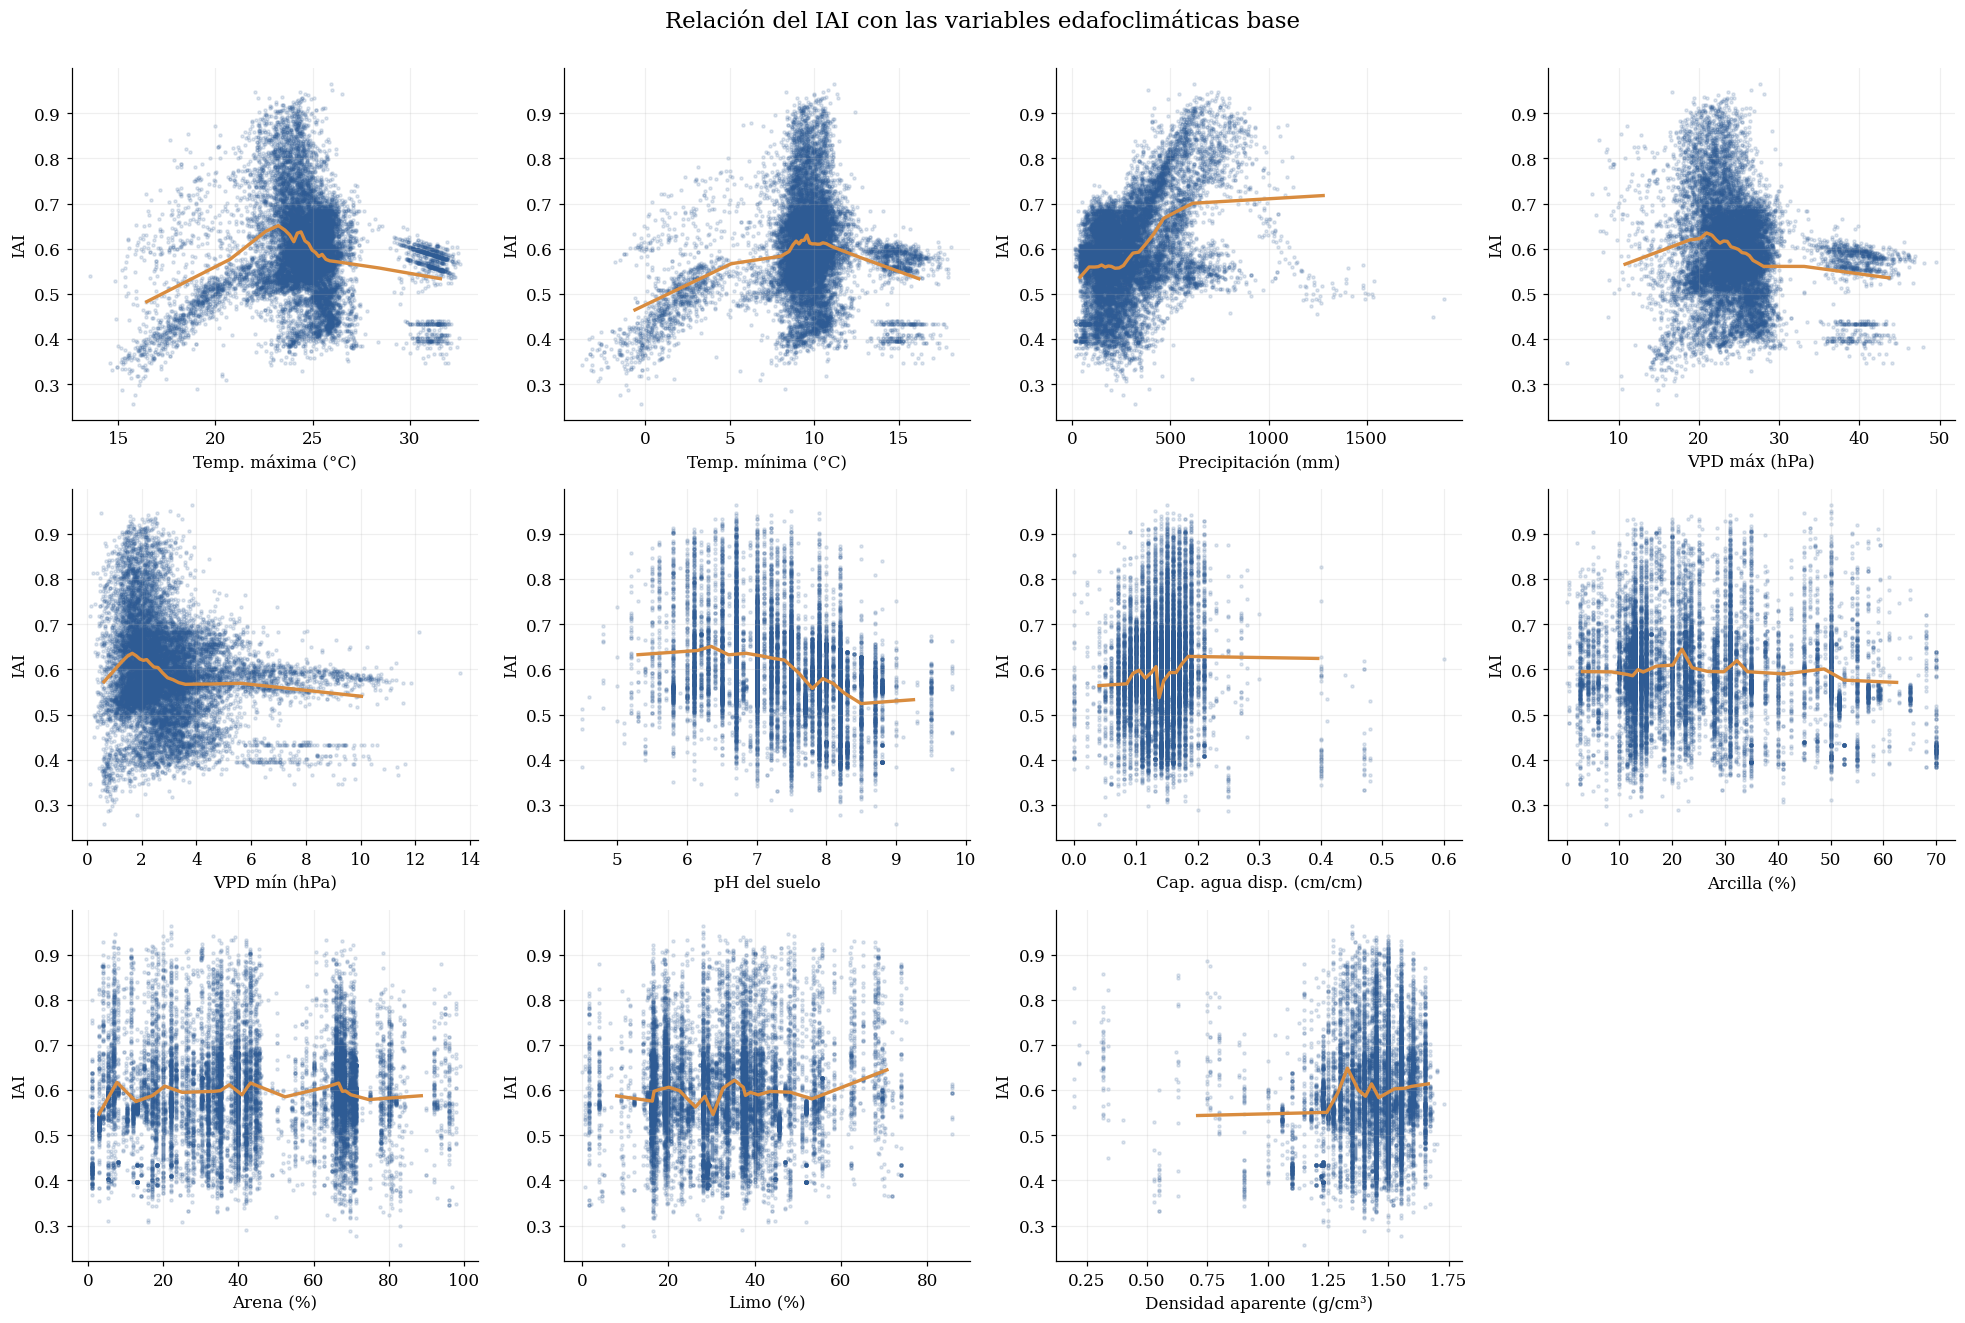

In [7]:
# Muestra para los scatter (eficiencia con datasets grandes)
np.random.seed(42)
n_muestra = min(15_000, df.shape[0])
idx = np.random.choice(df.shape[0], size=n_muestra, replace=False)
df_s = df[idx]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(vars_base):
    ax = axes[i]
    x = df_s[var].to_numpy()
    y = df_s["IAI"].to_numpy()
    ax.scatter(x, y, s=4, alpha=0.15, color=COLOR_MAIN)

    # Línea de tendencia (media de IAI por percentiles de x)
    try:
        bins = np.percentile(x, np.linspace(0, 100, 21))
        bins = np.unique(bins)
        centros, medias = [], []
        for j in range(len(bins) - 1):
            m = (x >= bins[j]) & (x < bins[j + 1])
            if m.sum() > 0:
                centros.append((bins[j] + bins[j + 1]) / 2)
                medias.append(y[m].mean())
        ax.plot(centros, medias, color=COLOR_ORANGE, linewidth=2.2)
    except Exception:
        pass

    ax.set_xlabel(NOMBRES.get(var, var))
    ax.set_ylabel("IAI")
    ax.grid(alpha=0.2)

# Ocultar ejes sobrantes
for k in range(len(vars_base), len(axes)):
    axes[k].set_visible(False)

plt.suptitle("Relación del IAI con las variables edafoclimáticas base",
             fontsize=15, y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_02_iai_vs_variables.png"), dpi=300, bbox_inches="tight")
plt.show()

Temperatura (máxima y mínima): ambas muestran una relación en forma de joroba, con un punto óptimo (alrededor de 23–25 °C en la máxima) a partir del cual la idoneidad empieza a caer. Es el comportamiento esperado: ni el frío ni el calor extremo favorecen a los cultivos.
Precipitación: es de las relaciones más marcadas. El IAI sube con fuerza a medida que aumenta la lluvia y se estabiliza a partir de los 500–600 mm. Esto confirma que el agua es un factor clave en California, donde la escasez de precipitación limita buena parte del territorio.
VPD (déficit de presión de vapor): tienen una relación inversa, cuanto mayor es el estrés evaporativo, menor es la idoneidad
Variables de suelo (pH, textura, densidad): su efecto es más suave y difuso. La línea se mantiene bastante plana, lo que indica que el suelo influye menos que el clima sobre el IAI global, aunque el pH muestra una ligera preferencia por valores cercanos a la neutralidad.

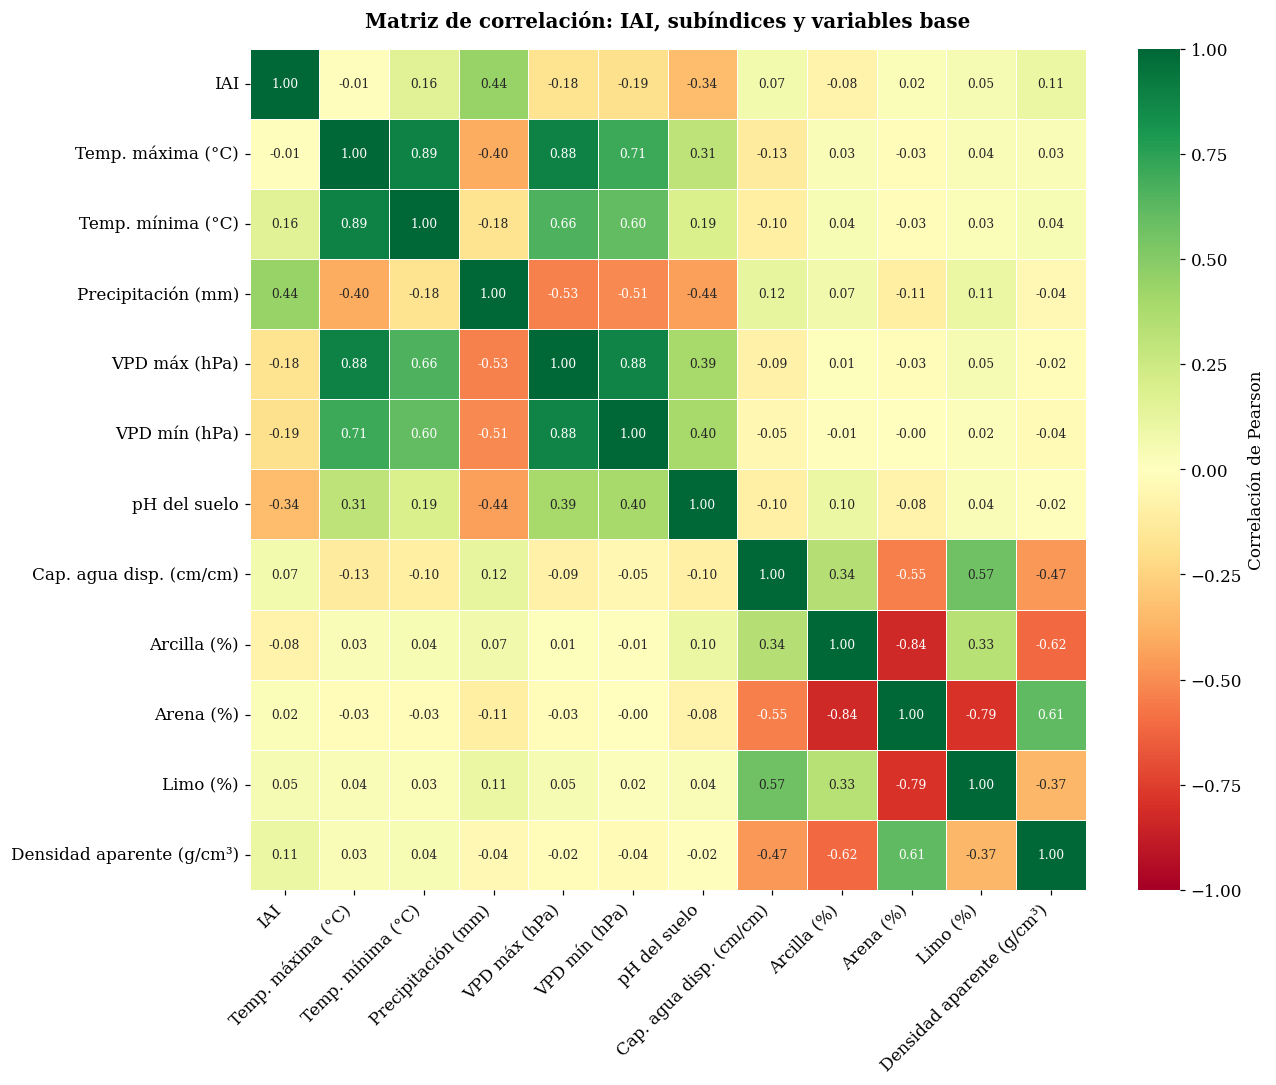

In [16]:
# Matriz de correlación
cols_corr = ["IAI"]  + vars_base
M = df.select(cols_corr).to_numpy()
corr = np.corrcoef(M, rowvar=False)

etiquetas = [NOMBRES.get(c, c) for c in cols_corr]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            xticklabels=etiquetas, yticklabels=etiquetas,
            vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
            annot_kws={"size": 8}, ax=ax, cbar_kws={"label": "Correlación de Pearson"})
ax.set_title("Matriz de correlación: IAI, subíndices y variables base", pad=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_06_matriz_correlacion.png"), dpi=300, bbox_inches="tight")
plt.show()

In [23]:
import numpy as np
import polars as pl
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr

# Variables a evaluar contra el IAI
vars_eval = subindices + vars_base
y = df["IAI"].to_numpy()

# Muestra para eficiencia (MI es costoso en 633k filas)
np.random.seed(42)
n = min(50_000, df.shape[0])
idx = np.random.choice(df.shape[0], size=n, replace=False)
y_s = y[idx]

resultados = []
for var in vars_eval:
    x = df[var].to_numpy()
    x_s = x[idx]

    # Pearson (lineal)
    pearson = np.corrcoef(x, y)[0, 1]

    # Spearman (monótona)
    spear = spearmanr(x, y).correlation

    # Información mutua (cualquier relación, normalizada a [0,~])
    mi = mutual_info_regression(x_s.reshape(-1, 1), y_s,
                                 random_state=42)[0]

    resultados.append({
        "variable": NOMBRES.get(var, var),
        "pearson": round(pearson, 3),
        "spearman": round(spear, 3),
        "info_mutua": round(mi, 3),
    })

df_corr = pl.DataFrame(resultados).sort("info_mutua", descending=True)
print(df_corr)

shape: (15, 4)
┌───────────────────────────┬─────────┬──────────┬────────────┐
│ variable                  ┆ pearson ┆ spearman ┆ info_mutua │
│ ---                       ┆ ---     ┆ ---      ┆ ---        │
│ str                       ┆ f64     ┆ f64      ┆ f64        │
╞═══════════════════════════╪═════════╪══════════╪════════════╡
│ I_GDD (térmico)           ┆ 0.443   ┆ 0.39     ┆ 1.32       │
│ I_suelo                   ┆ 0.324   ┆ 0.315    ┆ 0.709      │
│ Temp. máxima (°C)         ┆ -0.011  ┆ -0.085   ┆ 0.637      │
│ Precipitación (mm)        ┆ 0.441   ┆ 0.376    ┆ 0.511      │
│ I_precip                  ┆ 0.723   ┆ 0.639    ┆ 0.454      │
│ Arena (%)                 ┆ 0.024   ┆ 0.049    ┆ 0.45       │
│ I_temp                    ┆ 0.363   ┆ 0.298    ┆ 0.449      │
│ Limo (%)                  ┆ 0.051   ┆ 0.012    ┆ 0.441      │
│ Temp. mínima (°C)         ┆ 0.159   ┆ 0.101    ┆ 0.424      │
│ VPD máx (hPa)             ┆ -0.179  ┆ -0.155   ┆ 0.39       │
│ pH del suelo           

Para complementar la correlación de Pearson que solo mide relaciones lineales, se calcularon también la correlación de Spearman (relaciones monótonas) y la información mutua (cualquier tipo de dependencia, lineal o no). Con esto tenemos un overview del panorama más amplio ya que como vimos en los graficos las variables no tienen una relación lineal con IAI.

- El caso de la temperatura máxima muestra la importancia de usar la información mutua, ya que mientras que su correlación de Pearson es prácticamente nula (-0.01), su información mutua es una de las más altas (0.64). 


### IAI por cultivo

In [20]:
# IAI medio por cultivo (tabla)
resumen_cultivo = (
    df.group_by("crop_name")
      .agg([
          pl.col("IAI").mean().alias("IAI_medio"),
          pl.col("IAI").median().alias("IAI_mediana"),
          pl.col("IAI").std().alias("IAI_std"),
          pl.len().alias("n"),
      ])
      .sort("IAI_medio", descending=True)
)
print(resumen_cultivo)

shape: (12, 5)
┌──────────────┬───────────┬─────────────┬──────────┬────────┐
│ crop_name    ┆ IAI_medio ┆ IAI_mediana ┆ IAI_std  ┆ n      │
│ ---          ┆ ---       ┆ ---         ┆ ---      ┆ ---    │
│ str          ┆ f64       ┆ f64         ┆ f64      ┆ u32    │
╞══════════════╪═══════════╪═════════════╪══════════╪════════╡
│ Pistachios   ┆ 0.665279  ┆ 0.654005    ┆ 0.073125 ┆ 38503  │
│ Almonds      ┆ 0.659715  ┆ 0.639317    ┆ 0.086684 ┆ 136199 │
│ Strawberries ┆ 0.654221  ┆ 0.63038     ┆ 0.098364 ┆ 2117   │
│ Walnuts      ┆ 0.654105  ┆ 0.623856    ┆ 0.087098 ┆ 42355  │
│ Alfalfa      ┆ 0.600457  ┆ 0.602514    ┆ 0.114394 ┆ 136325 │
│ Tomatoes     ┆ 0.572086  ┆ 0.552586    ┆ 0.085285 ┆ 26379  │
│ Wheat        ┆ 0.567987  ┆ 0.550403    ┆ 0.123856 ┆ 76469  │
│ Grapes       ┆ 0.565206  ┆ 0.557242    ┆ 0.063742 ┆ 83068  │
│ Rice         ┆ 0.553218  ┆ 0.551954    ┆ 0.028901 ┆ 51469  │
│ Oranges      ┆ 0.46345   ┆ 0.463437    ┆ 0.026958 ┆ 10663  │
│ Lettuce      ┆ 0.447956  ┆ 0.433333   

C:\Users\lesli\AppData\Local\Temp\ipykernel_15912\1288147232.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_box, labels=orden, patch_artist=True,


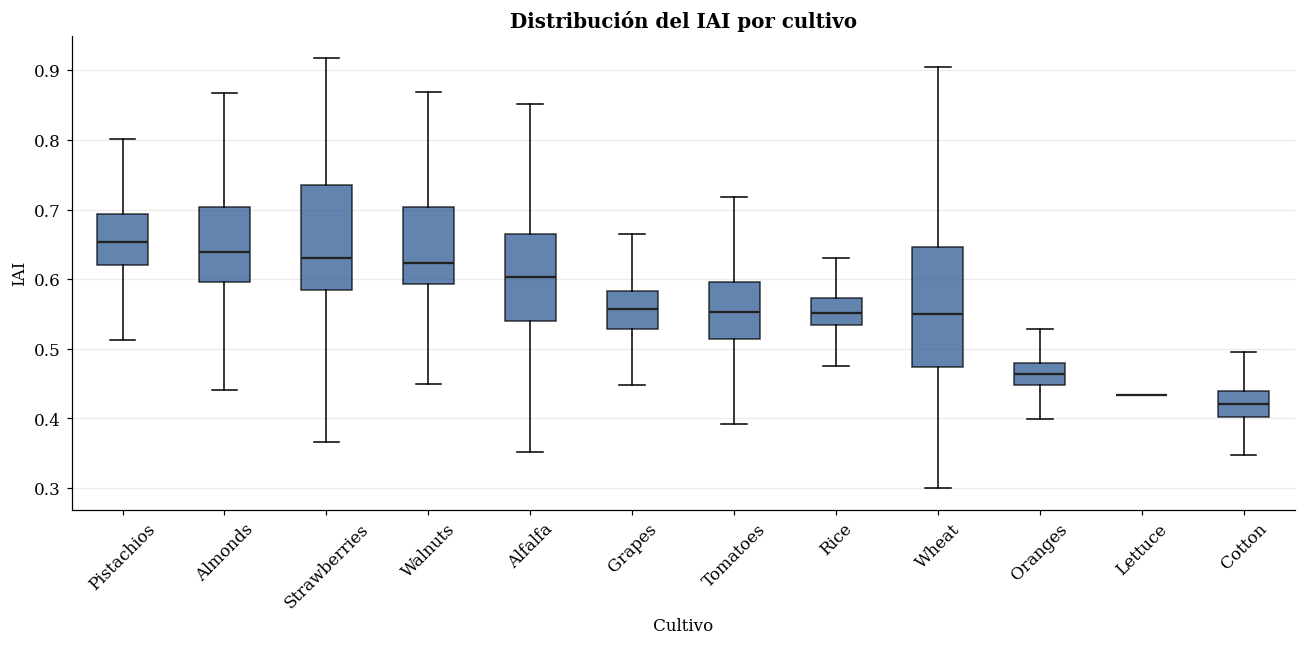

In [12]:
# Boxplot del IAI por cultivo, ordenado por mediana
orden = (df.group_by("crop_name")
           .agg(pl.col("IAI").median().alias("m"))
           .sort("m", descending=True)["crop_name"].to_list())

datos_box = [df.filter(pl.col("crop_name") == c)["IAI"].to_numpy() for c in orden]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(datos_box, labels=orden, patch_artist=True,
                showfliers=False, medianprops=dict(color="#222", linewidth=1.5))
for patch in bp["boxes"]:
    patch.set_facecolor(COLOR_MAIN)
    patch.set_alpha(0.75)
ax.set_ylabel("IAI")
ax.set_xlabel("Cultivo")
ax.set_title("Distribución del IAI por cultivo")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_05_iai_por_cultivo.png"), dpi=300, bbox_inches="tight")
plt.show()